
### Từ Raw Text → Feature Extraction → Model Training → Evaluation

---

Trong bài này, chúng ta sẽ xây dựng một mô hình **phân loại cảm xúc** (Sentiment Analysis) cho các đánh giá phim từ IMDB. Mục tiêu là phân loại mỗi review là **Positive** (tích cực) hay **Negative** (tiêu cực).

**Pipeline tổng quan:**
```
Raw Text → Preprocessing → Feature Extraction (BoW / TF-IDF) → Train Model → Evaluate & Compare
```

**Dataset:** IMDB Movie Reviews — 50,000 reviews, cân bằng 50/50 giữa positive và negative.

---
## Bước 1: Import thư viện


In [ ]:
# === Standard Libraries ===
import re
import warnings
warnings.filterwarnings('ignore')

# === Data Manipulation ===
import pandas as pd
import numpy as np

# === NLP ===
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize.toktok import ToktokTokenizer
from nltk.stem.porter import PorterStemmer

# === Feature Extraction ===
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# === Model Training ===
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# === Evaluation ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Download NLTK resources (chỉ cần chạy 1 lần)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)


ModuleNotFoundError: No module named 'nltk'

---
## Bước 2: Load dữ liệu

Dataset IMDB chứa 50,000 movie reviews từ trang web IMDB, được gán nhãn thủ công là `positive` hoặc `negative`.

In [ ]:
# !unzip "IMDB Dataset.csv.zip" -d data

Archive:  IMDB Dataset.csv.zip
  inflating: data/IMDB Dataset.csv   


In [ ]:
# Load data
df = pd.read_csv("data/Dataset.csv")

print("=" * 50)
print(f"Kích thước dataset: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Các cột: {list(df.columns)}")
print("=" * 50)

df.head(3)

Kích thước dataset: 50,000 dòng × 2 cột
Các cột: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


---
## Bước 3: Exploratory Data Analysis (EDA)

Trước khi xử lý bất kỳ điều gì, chúng ta cần **hiểu dữ liệu**:
- Phân bố nhãn có cân bằng không?
- Độ dài review như thế nào?
- Có missing values không?

In [ ]:
# --- Kiểm tra missing values ---
print("Missing values:")
print(df.isnull().sum())

# --- Phân bố nhãn ---
print("\n Phân bố nhãn (Sentiment):")
label_counts = df['sentiment'].value_counts()
print(label_counts)
print(f"\n→ Tỷ lệ: {label_counts['positive']/len(df)*100:.1f}% positive / {label_counts['negative']/len(df)*100:.1f}% negative")

Missing values:
review       0
sentiment    0
dtype: int64

 Phân bố nhãn (Sentiment):
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

→ Tỷ lệ: 50.0% positive / 50.0% negative


Thống kê độ dài review (số từ):
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


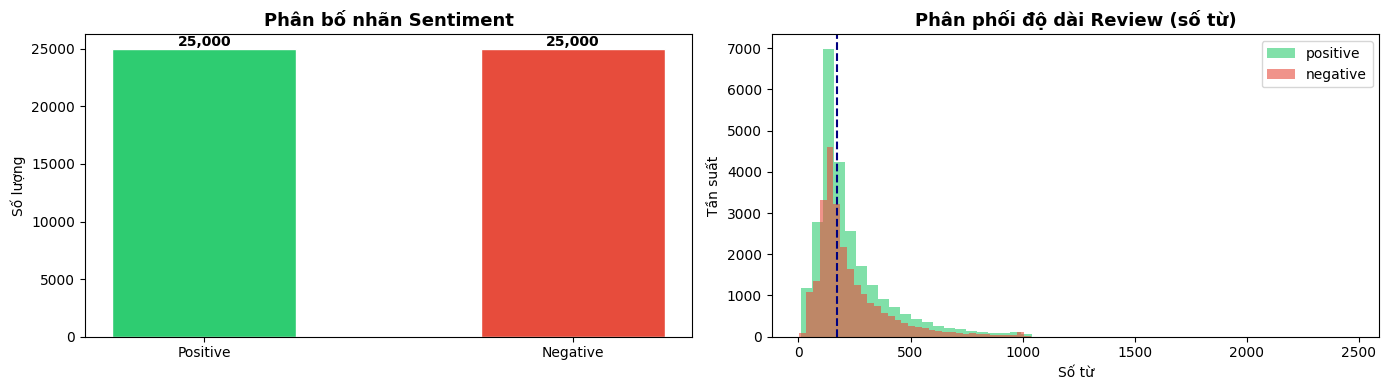


Nhận xét: Reviews khá dài (median ~150 từ), phân bố lệch phải — có một số review rất dài.


In [ ]:
# --- Phân tích độ dài review ---
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("Thống kê độ dài review (số từ):")
print(df.groupby('sentiment')['review_length'].describe().round(1))

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Phân bố nhãn
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Positive', 'Negative'], label_counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Phân bố nhãn Sentiment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Phân phối độ dài
for sentiment, color in zip(['positive', 'negative'], colors):
    data = df[df['sentiment'] == sentiment]['review_length']
    axes[1].hist(data, bins=50, alpha=0.6, color=color, label=sentiment)
axes[1].set_title('Phân phối độ dài Review (số từ)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Tần suất')
axes[1].legend()
axes[1].axvline(df['review_length'].median(), color='navy', linestyle='--', label=f'Median: {df["review_length"].median():.0f}')

plt.tight_layout()
plt.savefig('data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nNhận xét: Reviews khá dài (median ~150 từ), phân bố lệch phải — có một số review rất dài.")

---
## Bước 4: Text Preprocessing

Đây là bước **quan trọng nhất** trong NLP. Raw text từ web rất "bẩn" — chứa HTML tags, ký tự đặc biệt, stopwords vô nghĩa, và các biến thể của cùng một từ.

**Thứ tự xử lý đúng:**
```
1. Strip HTML tags     → loại bỏ <br>, <p>, ...
2. Remove noise        → loại bỏ [text trong ngoặc vuông]
3. Lowercase           → "Movie" và "movie" là một
4. Remove special chars → loại bỏ @#$%^&*
5. Remove stopwords    → loại bỏ "the", "is", "a", ...
6. Stemming            → "running" → "run", "movies" → "movi"
```


In [ ]:
# === Khởi tạo các công cụ NLP ===
tokenizer = ToktokTokenizer()
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Giữ lại một số từ phủ định quan trọng cho sentiment analysis!
# "not", "no", "never" rất quan trọng để phân biệt tích cực/tiêu cực
words_to_keep = {'not', 'no', 'never', 'nor', 'neither', 'nothing', 'nobody', 'nowhere', 'none'}
stop_words = stop_words - words_to_keep

print(f"Số stopwords: {len(stop_words)} (đã giữ lại các từ phủ định quan trọng)")
print(f"Các từ phủ định được giữ lại: {words_to_keep}")

Số stopwords: 195 (đã giữ lại các từ phủ định quan trọng)
Các từ phủ định được giữ lại: {'nothing', 'nor', 'nobody', 'nowhere', 'neither', 'no', 'not', 'never', 'none'}


In [ ]:
# =====================================================
# Định nghĩa từng bước preprocessing — tách rõ ràng
# để dễ debug và test từng bước
# =====================================================

def step1_strip_html(text: str) -> str:
    """
    Bước 1: Loại bỏ HTML tags.
    IMDB reviews có thể chứa: <br />, <p>, <b>, ...
    BeautifulSoup xử lý tốt hơn regex vì hiểu cấu trúc HTML.
    """
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()


def step2_remove_square_brackets(text: str) -> str:
    """
    Bước 2: Loại bỏ nội dung trong [...]
    Ví dụ: [SPOILER], [citation needed], ...
    Dùng raw string r'...' để tránh SyntaxWarning.
    """
    return re.sub(r'\[[^\]]*\]', '', text)


def step3_to_lowercase(text: str) -> str:
    """
    Bước 3: Lowercase toàn bộ.
    "Movie" và "movie" nên được coi là một.
    Phải làm TRƯỚC khi remove special chars và stopwords.
    """
    return text.lower()


def step4_remove_special_chars(text: str) -> str:
    """
    Bước 4: Chỉ giữ lại chữ cái và khoảng trắng.
    Loại bỏ: @, #, $, %, !, ?, số, ...
    Lưu ý: Sau bước này text đã lowercase nên [a-z] là đủ.
    """
    return re.sub(r'[^a-z\s]', '', text)


def step5_remove_stopwords(text: str) -> str:
    """
    Bước 5: Loại bỏ stopwords.
    Stopwords là các từ phổ biến không mang nhiều ý nghĩa:
    'the', 'a', 'is', 'in', 'at', ...
    Phải làm TRƯỚC stemming để đảm bảo match đúng với stopwords list.
    """
    tokens = tokenizer.tokenize(text)
    filtered = [token for token in tokens if token.strip() not in stop_words]
    return ' '.join(filtered)


def step6_stemming(text: str) -> str:
    """
    Bước 6: Stemming — rút gốc từ.
    Porter Stemmer cắt suffix để đưa về dạng gốc:
    'running' → 'run', 'movies' → 'movi', 'beautiful' → 'beauti'
    Giúp giảm vocabulary size và group các biến thể cùng nghĩa.
    """
    return ' '.join([stemmer.stem(word) for word in text.split()])


def preprocess_text(text: str) -> str:
    """
    Pipeline tổng hợp — gọi tuần tự theo đúng thứ tự.
    Hàm này là entry point duy nhất cho preprocessing.
    """
    text = step1_strip_html(text)
    text = step2_remove_square_brackets(text)
    text = step3_to_lowercase(text)
    text = step4_remove_special_chars(text)
    text = step5_remove_stopwords(text)
    text = step6_stemming(text)
    return text.strip()


In [ ]:
# === Kiểm tra thử trên 1 ví dụ trước khi apply toàn bộ ===
sample = df['review'].iloc[0]
print("REVIEW GỐC (100 ký tự đầu):")
print(sample[:200])
print()

print("SAU TỪNG BƯỚC:")
t = sample
t = step1_strip_html(t);           print(f"Step 1 - Strip HTML:     {t[:150]}")
t = step2_remove_square_brackets(t); print(f"Step 2 - Remove []:      {t[:150]}")
t = step3_to_lowercase(t);         print(f"Step 3 - Lowercase:      {t[:150]}")
t = step4_remove_special_chars(t); print(f"Step 4 - Remove special: {t[:150]}")
t = step5_remove_stopwords(t);     print(f"Step 5 - Stopwords:      {t[:150]}")
t = step6_stemming(t);             print(f"Step 6 - Stemming:       {t[:150]}")

REVIEW GỐC (100 ký tự đầu):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

SAU TỪNG BƯỚC:
Step 1 - Strip HTML:     One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with
Step 2 - Remove []:      One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with
Step 3 - Lowercase:      one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with
Step 4 - Remove special: one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with met
Step 5 - Stopwords:      one reviewers mentioned wa

In [ ]:
# === Apply preprocessing lên toàn bộ dataset ===

print("Đang xử lý 50,000 reviews")

df_clean = df.copy()
df_clean['cleaned_review'] = df_clean['review'].apply(preprocess_text)

# Encode nhãn: positive=1, negative=0
df_clean['label'] = df_clean['sentiment'].map({'positive': 1, 'negative': 0})

# Kiểm tra kết quả
print(f"\nXử lý xong! Shape: {df_clean.shape}")
print(f"\nSố review rỗng sau preprocessing: {(df_clean['cleaned_review'].str.strip() == '').sum()}")

# So sánh trước/sau
print("\n--- Ví dụ so sánh trước/sau ---")
idx = 5
print(f"Gốc:    {df_clean['review'].iloc[idx][:200]}")
print(f"Cleaned: {df_clean['cleaned_review'].iloc[idx][:200]}")

Đang xử lý 50,000 reviews

Xử lý xong! Shape: (50000, 5)

Số review rỗng sau preprocessing: 0

--- Ví dụ so sánh trước/sau ---
Gốc:    Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my having seen it some 15 or mo
Cleaned: probabl alltim favorit movi stori selfless sacrific dedic nobl caus not preachi bore never get old despit seen time last year paul luka perform bring tear eye bett davi one truli sympathet role deligh


In [ ]:
# === Lưu cleaned data để tái sử dụng ===
df_clean[['cleaned_review', 'label', 'sentiment']].to_csv('data/cleaned_imdb_data.csv', index=False)
print("Đã lưu: data/cleaned_imdb_data.csv")
print(f"\nPreview:")
df_clean[['cleaned_review', 'sentiment', 'label']].head(3)

Đã lưu: data/cleaned_imdb_data.csv

Preview:


,cleaned_review,sentiment,label
0,one review mention watch oz episod youll hook ...,positive,1
1,wonder littl product film techniqu unassum old...,positive,1
2,thought wonder way spend time hot summer weeke...,positive,1


---
## Bước 5: Train/Test Split


In [ ]:
X = df_clean['cleaned_review']
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 80% train, 20% test
    random_state=42,       # Cố định seed
    stratify=y             # Giữ nguyên tỷ lệ nhãn ở cả train và test
)

print("=" * 45)
print(f"Train size: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size:  {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print("=" * 45)
print(f"\nKiểm tra tỷ lệ nhãn trong Train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nKiểm tra tỷ lệ nhãn trong Test:")
print(y_test.value_counts(normalize=True).round(3))

Train size: 40,000 (80%)
Test size:  10,000  (20%)

Kiểm tra tỷ lệ nhãn trong Train:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Kiểm tra tỷ lệ nhãn trong Test:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
